## Dataset Preparation
Feature and Target Sepearation

In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

words = open('../data/names.txt', 'r').read().splitlines()

In [2]:
chars = sorted(set(''.join(words)))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {s:i for i,s in stoi.items()}

# itos[1] = 'a'
# stoi['a'] = 1

In [3]:
CONTEXT_SIZE = 5

X = []
y = []
for w in words:
    # print(w)
    context = [0] * CONTEXT_SIZE
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)

        context = context[1:] + [ix]
        # print(''.join(itos[i] for i in context), '--->', itos[ix])


# X is [x1, x2, x3, ... xN] 
X = torch.tensor(X)
y = torch.tensor(y)

In [4]:
DIM_SIZE = 10

# C is an embedded dimension
C = torch.randn((27, DIM_SIZE))

# OHE, but we do it algebraically (it's the same zero cancel out effect)
emb = C[X]

print(X.shape)
print(C.shape)
print(emb.shape)

torch.Size([228146, 5])
torch.Size([27, 10])
torch.Size([228146, 5, 10])


In [5]:
W1 = torch.randn((CONTEXT_SIZE * DIM_SIZE, 100))
B1 = torch.randn(100)

h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + B1)
h.shape

torch.Size([228146, 100])

In [6]:
W2 = torch.randn((100, 27))
B2 = torch.randn(27)

logits = h @ W2 + B2
counts = logits.exp()
probs = counts/counts.sum(1, keepdims=True)


## Unified Version

In [16]:
def build_dataset(words):
    X = []
    y = []
    for w in words:
        # print(w)
        context = [0] * CONTEXT_SIZE
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)

            context = context[1:] + [ix]
            # print(''.join(itos[i] for i in context), '--->', itos[ix])


    # X is [x1, x2, x3, ... xN] 
    X = torch.tensor(X)
    y = torch.tensor(y)

    return X, y

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, y_train = build_dataset(words[:n1])
X_dev, y_dev = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])

print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

torch.Size([182580, 3])
torch.Size([22767, 3])
torch.Size([22799, 3])


In [27]:
N = 500
g  = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, DIM_SIZE), generator=g) 
W1 = torch.randn((CONTEXT_SIZE * DIM_SIZE, N), generator=g)
b1 = torch.randn(N, generator=g)
W2 = torch.randn((N, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [37]:
import torch.nn.functional as F

epochs = 10000
batch  = 64
lr = 0.001


lre = torch.linspace(-3, 0, epochs)
lrs = 10**lre

lri = []
lossi = []
stepi = []

In [38]:
for i in range(2 * epochs):
    # forward pass
    ix = torch.randint(0, X_train.shape[0], (batch,))

    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01 if i < epochs else 0.001
    for p in parameters:
        p.data -= lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())

    if i % 100 == 0:
        print(f'loss {i}: {loss.item()}')

loss 0: 2.24723482131958
loss 100: 2.1183605194091797
loss 200: 2.2101309299468994
loss 300: 2.3185932636260986
loss 400: 2.0970611572265625
loss 500: 2.0594089031219482
loss 600: 2.254742383956909
loss 700: 2.1721608638763428
loss 800: 2.2068793773651123
loss 900: 2.2958085536956787
loss 1000: 2.462409734725952
loss 1100: 2.239804983139038
loss 1200: 2.0896403789520264
loss 1300: 1.9865267276763916
loss 1400: 2.0518736839294434
loss 1500: 2.362666130065918
loss 1600: 2.2259035110473633
loss 1700: 2.162052631378174
loss 1800: 2.129754066467285
loss 1900: 2.028569459915161
loss 2000: 2.250758647918701
loss 2100: 2.373720645904541
loss 2200: 1.8610509634017944
loss 2300: 2.0340356826782227
loss 2400: 2.2911834716796875
loss 2500: 2.0217158794403076
loss 2600: 1.8564717769622803
loss 2700: 1.9989356994628906
loss 2800: 1.9704699516296387
loss 2900: 2.0705599784851074
loss 3000: 2.3269543647766113
loss 3100: 2.3227763175964355
loss 3200: 2.0502519607543945
loss 3300: 1.9931635856628418
los

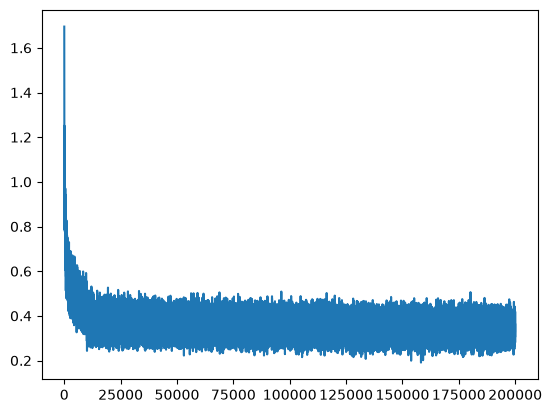

In [31]:
plt.plot(stepi, lossi)

In [39]:
emb = C[X_train]
h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, y_train)

loss.item()

2.175909996032715

In [40]:
emb = C[X_dev]
h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, y_dev)

loss.item()

2.227116584777832

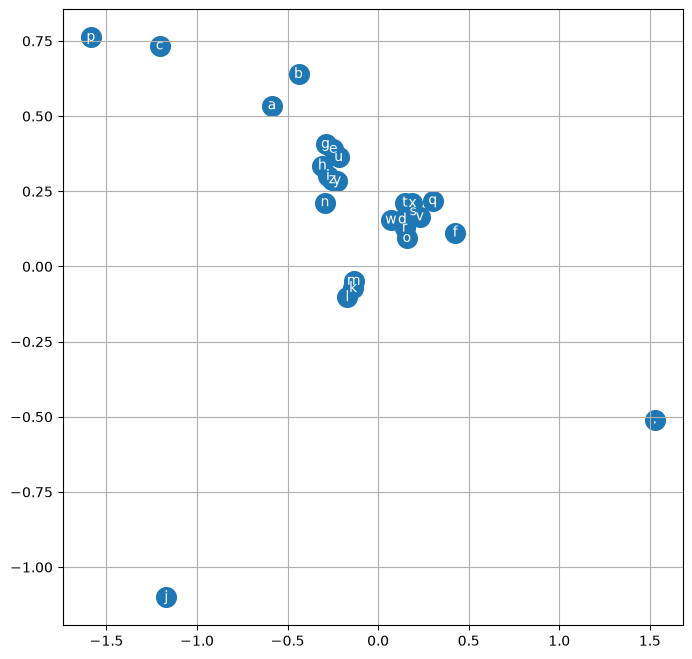

In [41]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [45]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * CONTEXT_SIZE # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)

      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]

      if ix == 0:
        break

      out.append(ix)
    
    print(''.join(itos[i] for i in out))

carpeleah
jhl
khy
mili
taty
skanden
jazontefahliah
jareei
ner
kiahceaiir
kaleigh
ham
joce
quinn
shlin
alian
quis
elo
dearixi
jaxeenissa
